In [35]:
import os
os.chdir(r"E:\LogAnomalyDetector")
os.getcwd()


'E:\\LogAnomalyDetector'

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


In [37]:
df = pd.read_csv("data/labeled_logs.csv")
df.head()


,timestamp,message,true_label
0,2025-07-23 16:11:43,LEVEL=INFO IP=192.168.1.100,0
1,2025-07-23 16:13:22,LEVEL=WARNING IP=192.168.1.101,0
2,2025-07-23 16:15:11,LEVEL=ERROR IP=nan,1
3,2025-07-23 16:18:53,LEVEL=INFO IP=nan,0
4,2025-07-23 16:21:08,LEVEL=CRITICAL IP=192.168.1.105,1


In [38]:
X_text = df["message"].astype(str)
y_true = df["true_label"].values

len(X_text), len(y_true)


(5, 5)

In [39]:
vectorizer = joblib.load("models/tfidf_vectorizer.joblib")
model = joblib.load("models/best_model.joblib")


In [40]:
X_all = vectorizer.transform(X_text)
X_all.shape


(5, 300)

In [41]:
y_prob = model.predict_proba(X_all)[:, 1]
y_pred = model.predict(X_all)

len(y_prob), len(y_pred)


(5, 5)

In [42]:
os.makedirs("reports", exist_ok=True)


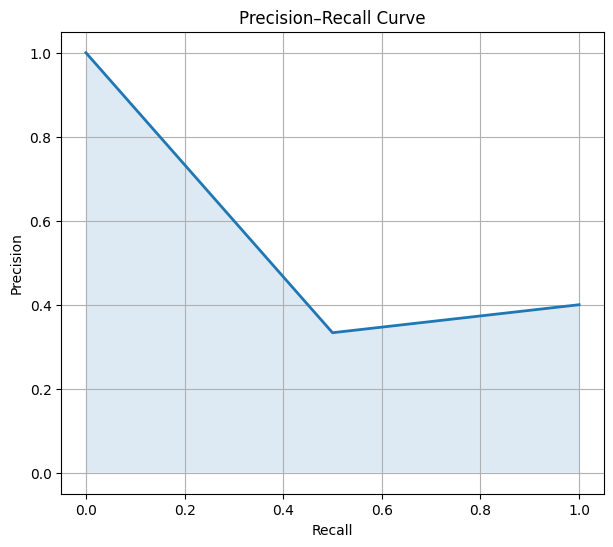

In [43]:
precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, linewidth=2)
plt.fill_between(recall, precision, alpha=0.15)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)

plt.savefig("reports/precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()


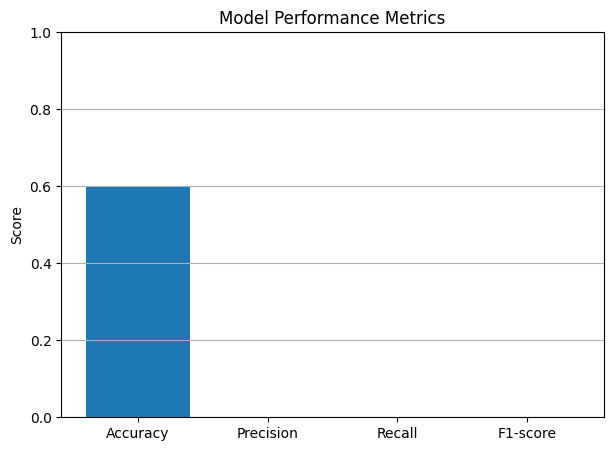

{'Accuracy': 0.6, 'Precision': 0.0, 'Recall': 0.0, 'F1-score': 0.0}

In [44]:
metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, zero_division=0),
    "Recall": recall_score(y_true, y_pred),
    "F1-score": f1_score(y_true, y_pred)
}

plt.figure(figsize=(7, 5))
plt.bar(metrics.keys(), metrics.values())
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Metrics")
plt.grid(axis="y")

plt.savefig("reports/model_performance_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

metrics


In [45]:
import numpy as np

np.percentile(y_prob, [50, 60, 70, 80, 90, 95, 99])


array([0.11, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11])

In [46]:
import os
os.makedirs("reports", exist_ok=True)


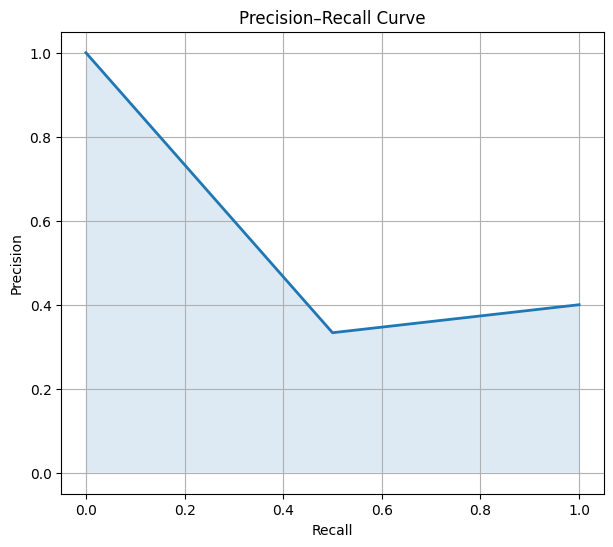

In [47]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, linewidth=2)
plt.fill_between(recall, precision, alpha=0.15)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)

plt.savefig("reports/precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()


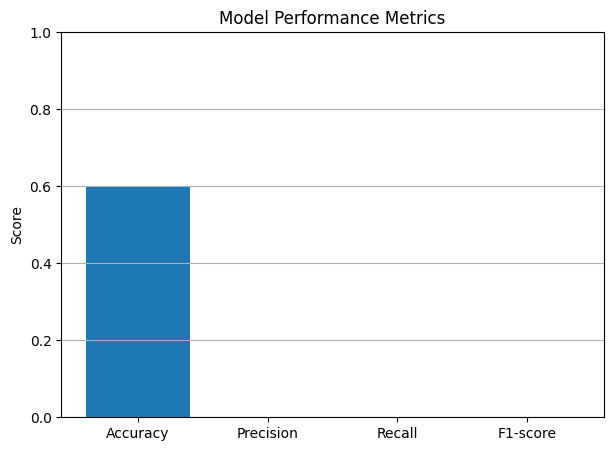

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, zero_division=0),
    "Recall": recall_score(y_true, y_pred),
    "F1-score": f1_score(y_true, y_pred)
}

plt.figure(figsize=(7, 5))
plt.bar(metrics.keys(), metrics.values())
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Metrics")
plt.grid(axis="y")

plt.savefig("reports/model_performance_metrics.png", dpi=300, bbox_inches="tight")
plt.show()


In [49]:
os.listdir("reports")


['confusion_matrix_adfa.png',
 'confusion_matrix_hdfs.png',
 'evaluation_results.json',
 'model_performance_metrics.png',
 'precision_recall_curve.png',
 'predicted_logs.csv']